In [21]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.config import np, plt, sp
import src.simulations as sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
a, p = sp.symbols('a p') # arrival and access probabilities symbols

P = sp.Matrix([
    [(1-a)**2,    a*(1-a),          a*(1-a),          a**2              ],
    [p*(1-a)**2,  (1-a)*(1-p+p*a),  p*a*(1-a),        a*(1-p+p*a)       ],
    [p*(1-a)**2,  p*a*(1-a),        (1-a)*(1-p+p*a),  a*(1-p+p*a)       ],
    [0,           p*(1-a)*(1-p),    p*(1-p)*(1-a),    p**2 + (1-p)*(1-p+2*p*a) ]
])

pi00s, pi01s, pi10s, pi11s = sp.symbols('pi00 pi01 pi10 pi11')
pi = sp.Matrix([pi00s, pi01s, pi10s, pi11s])

# equações: pi = pi P  e soma(pi)=1
eqs = list((pi.T * P - pi.T)[0,:])
eqs[-1] = pi00s + pi01s + pi10s + pi11s - 1
sol = sp.solve(eqs, [pi00s, pi01s, pi10s, pi11s], dict=True)
sol = sol[0]  # dicionário com pi00,pi01,pi10,pi11
pi00, pi01, pi10, pi11 = [sol[pi00s], sol[pi01s], sol[pi10s], sol[pi11s]]

In [29]:
throughput_expr = sp.simplify(pi01*p + pi10*p + 2*pi11*p*(1-p))
throughput_data = simulate_metric(sim.throughput, time=100000)

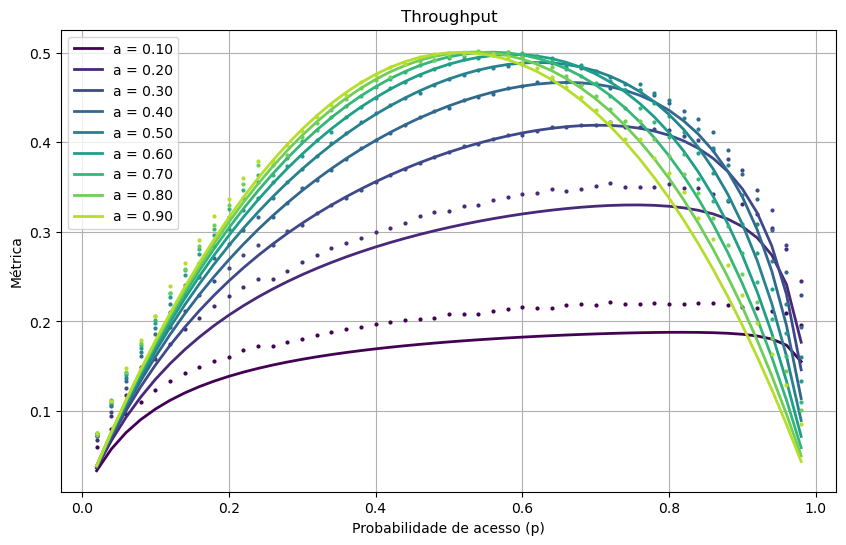

In [35]:
compare_metric_plot(
    analytical_expr=throughput_expr,
    simulated_data=throughput_data,
    title="Throughput",
    cmap="viridis",
    axis="p"
)

In [ ]:
# auto complete age expression
age_expr = sp.simplify((pi01 + pi10 + 2*pi11)/(throughput_expr))